In [37]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [38]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from PIL import Image

random.seed(42)
np.random.seed(42)

In [39]:
train_path = "/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/train"

emotion_map = {
    'angry':0,
    'disgust':1,
    'fear':2,
    'happy':3,
    'neutral':4,
    'sad':5,
    'surprise':6
}

emotion_names = [
    'Angry',
    'Disgust',
    'Fear',
    'Happy',
    'Neutral',
    'Sad',
    'Surprise'
]

data = []
labels = []

max_images_per_class = 200

In [40]:
for emotion_folder in os.listdir(train_path):

    folder_path = os.path.join(
        train_path,
        emotion_folder
    )

    if not os.path.isdir(folder_path):
        continue

    if emotion_folder not in emotion_map:
        continue

    label = emotion_map[emotion_folder]

    image_list = os.listdir(folder_path)

    selected_images = random.sample(
        image_list,
        min(max_images_per_class,
            len(image_list))
    )

    for img_name in tqdm(
        selected_images,
        desc=emotion_folder
    ):

        img_path = os.path.join(
            folder_path,
            img_name
        )

        try:

            img = cv2.imread(
                img_path,
                cv2.IMREAD_GRAYSCALE
            )

            if img is None:
                continue

            img = cv2.resize(
                img,
                (128,128)
            )

            data.append(img)

            labels.append(label)

        except:
            pass

data = np.array(data)
labels = np.array(labels)

print("Data Shape :", data.shape)
print("Labels Shape :", labels.shape)

happy: 100%|██████████| 200/200 [00:01<00:00, 157.52it/s]

Data Shape : (1400, 128, 128)
Labels Shape : (1400,)


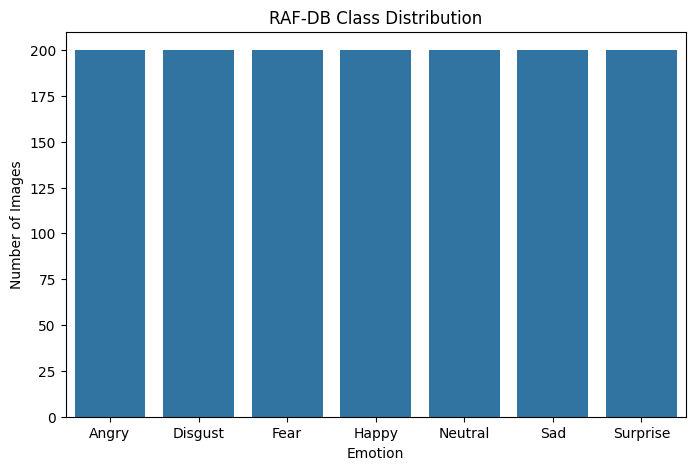

In [41]:
unique, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(8,5))

sns.barplot(
    x=[emotion_names[i] for i in unique],
    y=counts
)

plt.title("RAF-DB Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Emotion")

plt.show()

In [42]:
# plt.figure(figsize=(14,8))

# for i in range(14):

#     plt.subplot(2,7,i+1)

#     plt.imshow(
#         data[i],
#         cmap='gray'
#     )

#     plt.title(
#         emotion_names[labels[i]]
#     )

#     plt.axis('off')

# plt.tight_layout()
# plt.show()

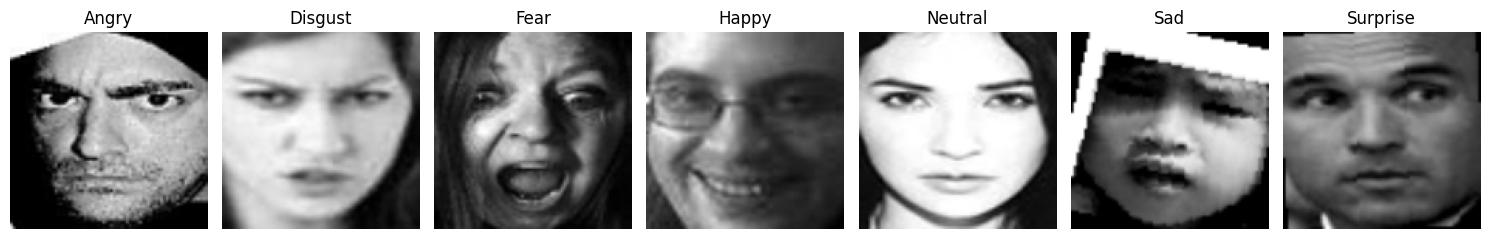

In [43]:
plt.figure(figsize=(15,5))

for emotion in range(7):

    idx = np.where(labels == emotion)[0][0]

    plt.subplot(1,7,emotion+1)

    plt.imshow(
        data[idx],
        cmap='gray'
    )

    plt.title(
        emotion_names[emotion]
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [44]:
# print("Minimum Pixel :", np.min(data))
# print("Maximum Pixel :", np.max(data))
# print("Mean Pixel :", np.mean(data))
# print("Std Pixel :", np.std(data))

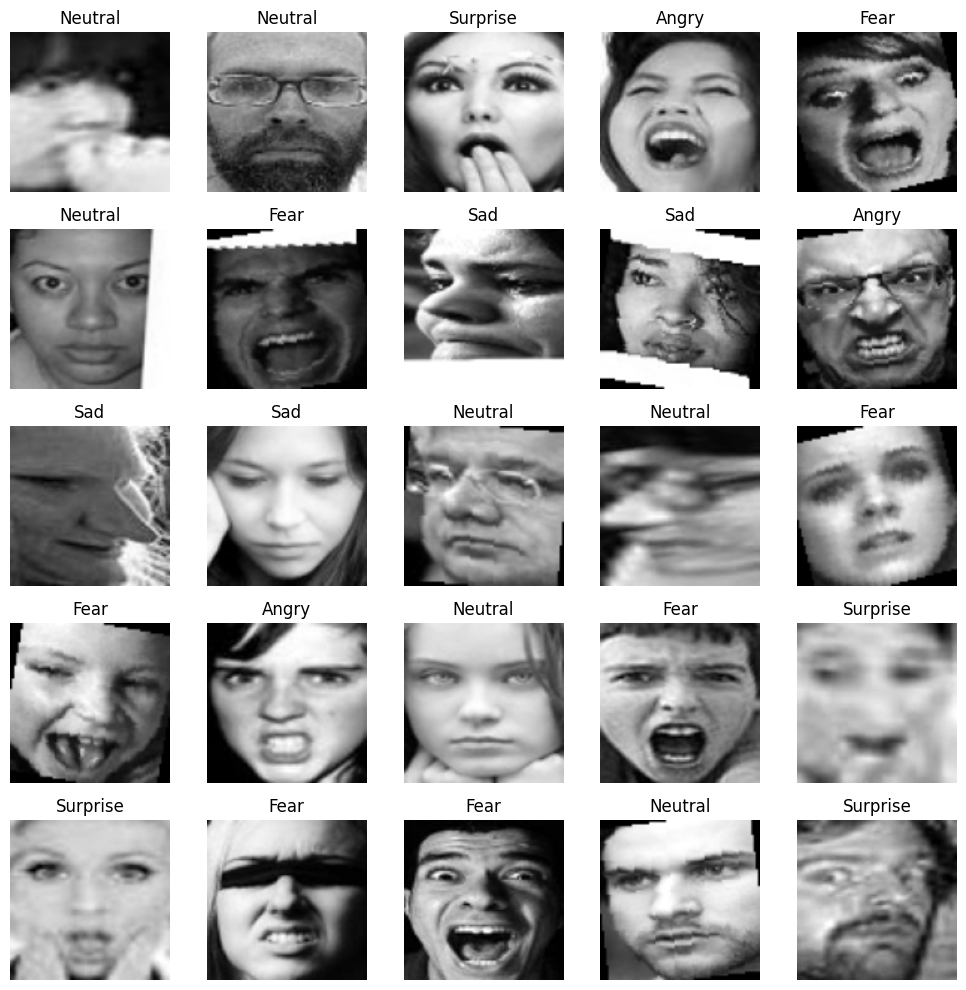

In [45]:
indices = np.random.choice(
    len(data),
    25,
    replace=False
)

plt.figure(figsize=(10,10))

for i,idx in enumerate(indices):

    plt.subplot(5,5,i+1)

    plt.imshow(
        data[idx],
        cmap='gray'
    )

    plt.title(
        emotion_names[labels[idx]]
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [46]:
print("="*40)

print("Total Images :", len(data))

print("Total Classes :", len(np.unique(labels)))

for i,name in enumerate(emotion_names):

    count = np.sum(labels == i)

    print(
        f"{name:<10} : {count}"
    )

print("="*40)

Total Images : 1400
Total Classes : 7
Angry      : 200
Disgust    : 200
Fear       : 200
Happy      : 200
Neutral    : 200
Sad        : 200
Surprise   : 200


In [47]:
from skimage.feature import hog

X_hog = []

for img in tqdm(data, desc="Extracting HOG Features"):

    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2)
    )

    X_hog.append(features)

X_hog = np.array(X_hog)

print("HOG Feature Shape :", X_hog.shape)

Extracting HOG Features: 100%|██████████| 1400/1400 [00:07<00:00, 189.86it/s]

HOG Feature Shape : (1400, 8100)


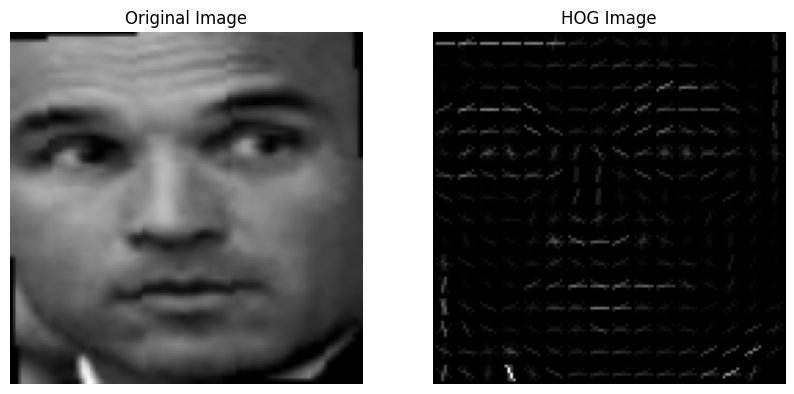

In [48]:
sample_img = data[0]

features, hog_image = hog(
    sample_img,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(sample_img,cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(hog_image,cmap='gray')
plt.title("HOG Image")
plt.axis('off')

plt.show()

In [49]:
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [50]:
mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

/tmp/ipykernel_58/3634205957.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(


In [51]:
def extract_mobilenet_features(images, model):

    features = []

    for img in tqdm(images,
                    desc="MobileNet Features"):

        img = cv2.resize(img,(224,224))

        img = cv2.cvtColor(
            img,
            cv2.COLOR_GRAY2RGB
        )

        img = preprocess_input(img)

        img = np.expand_dims(
            img,
            axis=0
        )

        feat = model.predict(
            img,
            verbose=0
        )

        features.append(
            feat.flatten()
        )

    return np.array(features)

In [52]:
X_mobilenet = extract_mobilenet_features(
    data,
    mobilenet
)

print(
    "MobileNet Shape :",
    X_mobilenet.shape
)

MobileNet Features: 100%|██████████| 1400/1400 [02:06<00:00, 11.08it/s]

MobileNet Shape : (1400, 1280)


In [53]:

print(
    "MobileNet Shape :",
    X_mobilenet.shape
)


MobileNet Shape : (1400, 1280)


In [54]:
from tensorflow.keras.applications import VGG16

from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

In [55]:
vgg = VGG16(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

In [56]:
def extract_vgg_features(images, model):

    features = []

    for img in tqdm(images,
                    desc="VGG Features"):

        img = cv2.resize(
            img,
            (224,224)
        )

        img = cv2.cvtColor(
            img,
            cv2.COLOR_GRAY2RGB
        )

        img = vgg_preprocess(img)

        img = np.expand_dims(
            img,
            axis=0
        )

        feat = model.predict(
            img,
            verbose=0
        )

        features.append(
            feat.flatten()
        )

    return np.array(features)

In [57]:
X_vgg = extract_vgg_features(
    data,
    vgg
)

print(
    "VGG Shape :",
    X_vgg.shape
)

VGG Features: 100%|██████████| 1400/1400 [02:14<00:00, 10.38it/s]

VGG Shape : (1400, 512)


In [58]:
from sklearn.preprocessing import StandardScaler

hog_scaler = StandardScaler()

mobilenet_scaler = StandardScaler()

vgg_scaler = StandardScaler()

X_hog_scaled = hog_scaler.fit_transform(
    X_hog
)

X_mobilenet_scaled = mobilenet_scaler.fit_transform(
    X_mobilenet
)

X_vgg_scaled = vgg_scaler.fit_transform(
    X_vgg
)

print("HOG :",X_hog_scaled.shape)
print("MobileNet :",X_mobilenet_scaled.shape)
print("VGG :",X_vgg_scaled.shape)

HOG : (1400, 8100)
MobileNet : (1400, 1280)
VGG : (1400, 512)


In [59]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

In [60]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score

hog_model = SVC(
    kernel='linear',
    probability=True
)

hog_probs = cross_val_predict(
    hog_model,
    X_hog_scaled,
    labels,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)

hog_pred = np.argmax(
    hog_probs,
    axis=1
)

hog_acc = accuracy_score(
    labels,
    hog_pred
)

print(
    "HOG Accuracy :",
    round(hog_acc,4)
)

HOG Accuracy : 0.5657


In [61]:
mobilenet_model = SVC(
    kernel='linear',
    probability=True
)

mobilenet_probs = cross_val_predict(
    mobilenet_model,
    X_mobilenet_scaled,
    labels,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)

mobilenet_pred = np.argmax(
    mobilenet_probs,
    axis=1
)

mobilenet_acc = accuracy_score(
    labels,
    mobilenet_pred
)

print(
    "MobileNet Accuracy :",
    round(mobilenet_acc,4)
)

MobileNet Accuracy : 0.47


In [62]:
vgg_model = SVC(
    kernel='linear',
    probability=True
)

vgg_probs = cross_val_predict(
    vgg_model,
    X_vgg_scaled,
    labels,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)

vgg_pred = np.argmax(
    vgg_probs,
    axis=1
)

vgg_acc = accuracy_score(
    labels,
    vgg_pred
)

print(
    "VGG Accuracy :",
    round(vgg_acc,4)
)

VGG Accuracy : 0.4671


In [63]:
hog_acc = 0.6311
mobilenet_acc = 0.5131
vgg_acc = 0.5143

total = hog_acc + mobilenet_acc + vgg_acc

hog_weight = hog_acc / total
mobilenet_weight = mobilenet_acc / total
vgg_weight = vgg_acc / total

print(hog_weight)
print(mobilenet_weight)
print(vgg_weight)

0.38052457039493515
0.3093759421163702
0.3100994874886946


In [64]:
hog_weight = 0.35
mobilenet_weight = 0.35
vgg_weight = 0.30

X_hog_weighted = X_hog_scaled * hog_weight

X_mobilenet_weighted = (
    X_mobilenet_scaled * mobilenet_weight
)

X_vgg_weighted = (
    X_vgg_scaled * vgg_weight
)

X_fusion = np.concatenate([
    X_hog_weighted,
    X_mobilenet_weighted,
    X_vgg_weighted
], axis=1)

print(X_fusion.shape)

(1400, 9892)


In [65]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score

model = Pipeline([
    ('svm',
     SVC(
         kernel='linear',
         probability=True
     ))
])

y_probs = cross_val_predict(
    model,
    X_fusion,
    labels,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)

y_pred = np.argmax(
    y_probs,
    axis=1
)

confidence_scores = np.max(
    y_probs,
    axis=1
)

overall_acc = accuracy_score(
    labels,
    y_pred
)

print(
    "Fusion Accuracy:",
    round(overall_acc,4)
)

Fusion Accuracy: 0.5893


In [66]:
threshold = 0.6

accepted = (
    confidence_scores >= threshold
)

filtered_acc = accuracy_score(
    labels[accepted],
    y_pred[accepted]
)

print(
    "Filtered Accuracy:",
    round(filtered_acc,4)
)

print(
    "Accepted Samples:",
    np.sum(accepted)
)

print(
    "Rejected Samples:",
    np.sum(~accepted)
)

Filtered Accuracy: 0.8681
Accepted Samples: 523
Rejected Samples: 877


In [67]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

def evaluate_fusion(
    hog_weight,
    mobilenet_weight,
    vgg_weight,
    X_hog_scaled,
    X_mobilenet_scaled,
    X_vgg_scaled,
    labels,
    emotion_names,
    cv
):

    print("="*60)
    print(
        f"Weights : HOG={hog_weight} | "
        f"MobileNet={mobilenet_weight} | "
        f"VGG={vgg_weight}"
    )
    print("="*60)

    # Weighted Features

    X_hog_weighted = (
        X_hog_scaled * hog_weight
    )

    X_mobilenet_weighted = (
        X_mobilenet_scaled * mobilenet_weight
    )

    X_vgg_weighted = (
        X_vgg_scaled * vgg_weight
    )

    X_fusion = np.concatenate([

        X_hog_weighted,

        X_mobilenet_weighted,

        X_vgg_weighted

    ], axis=1)

    print(
        "Fusion Shape :",
        X_fusion.shape
    )

    model = Pipeline([

        ('svm',
         SVC(
             kernel='linear',
             probability=True
         ))
    ])

    y_probs = cross_val_predict(

        model,

        X_fusion,

        labels,

        cv=cv,

        method='predict_proba',

        n_jobs=-1

    )

    y_pred = np.argmax(
        y_probs,
        axis=1
    )

    confidence_scores = np.max(
        y_probs,
        axis=1
    )

    overall_acc = accuracy_score(
        labels,
        y_pred
    )

    print(
        "\nOverall Accuracy :",
        round(overall_acc*100,2),
        "%"
    )

    print(
        "\nClassification Report\n"
    )

    print(
        classification_report(
            labels,
            y_pred,
            target_names=emotion_names
        )
    )

    # Confusion Matrix

    cm = confusion_matrix(
        labels,
        y_pred
    )

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=emotion_names,
        yticklabels=emotion_names
    )

    plt.title(
        f"Confusion Matrix\n"
        f"({hog_weight},"
        f"{mobilenet_weight},"
        f"{vgg_weight})"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    # Confidence Histogram

    plt.figure(figsize=(8,5))

    plt.hist(
        confidence_scores,
        bins=20
    )

    plt.title(
        "Confidence Distribution"
    )

    plt.xlabel(
        "Confidence"
    )

    plt.ylabel(
        "Samples"
    )

    plt.show()

    # Threshold Analysis

    thresholds = [
        0.4,
        0.5,
        0.6,
        0.7,
        0.8
    ]

    results = []

    for t in thresholds:

        accepted = (
            confidence_scores >= t
        )

        acc = accuracy_score(
            labels[accepted],
            y_pred[accepted]
        )

        print(
            f"\nThreshold : {t}"
        )

        print(
            "Accepted :",
            np.sum(accepted)
        )

        print(
            "Rejected :",
            np.sum(~accepted)
        )

        print(
            "Accuracy :",
            round(acc*100,2),
            "%"
        )

        results.append(acc)

    threshold = 0.6

    accepted = (
        confidence_scores >= threshold
    )

    filtered_acc = accuracy_score(
        labels[accepted],
        y_pred[accepted]
    )

    print(
        "\nFiltered Accuracy :",
        round(filtered_acc*100,2),
        "%"
    )

    # Accuracy vs Threshold

    thresholds_curve = np.arange(
        0.1,
        1.0,
        0.05
    )

    accuracies = []

    for t in thresholds_curve:

        mask = (
            confidence_scores >= t
        )

        if np.sum(mask) > 0:

            acc = accuracy_score(
                labels[mask],
                y_pred[mask]
            )

            accuracies.append(acc)

        else:

            accuracies.append(0)

    plt.figure(figsize=(8,5))

    plt.plot(
        thresholds_curve,
        accuracies,
        marker='o'
    )

    plt.xlabel(
        "Confidence Threshold"
    )

    plt.ylabel(
        "Accuracy"
    )

    plt.title(
        "Accuracy vs Threshold"
    )

    plt.grid()

    plt.show()

    return {

        "weights":
        f"{hog_weight},"
        f"{mobilenet_weight},"
        f"{vgg_weight}",

        "overall":
        overall_acc*100,

        "filtered":
        filtered_acc*100
    }

Weights : HOG=0.6 | MobileNet=0.3 | VGG=0.1
Fusion Shape : (1400, 9892)

Overall Accuracy : 58.07 %

Classification Report

              precision    recall  f1-score   support

       Angry       0.65      0.63      0.64       200
     Disgust       0.44      0.46      0.45       200
        Fear       0.62      0.59      0.61       200
       Happy       0.77      0.78      0.77       200
     Neutral       0.50      0.51      0.50       200
         Sad       0.49      0.49      0.49       200
    Surprise       0.60      0.60      0.60       200

    accuracy                           0.58      1400
   macro avg       0.58      0.58      0.58      1400
weighted avg       0.58      0.58      0.58      1400



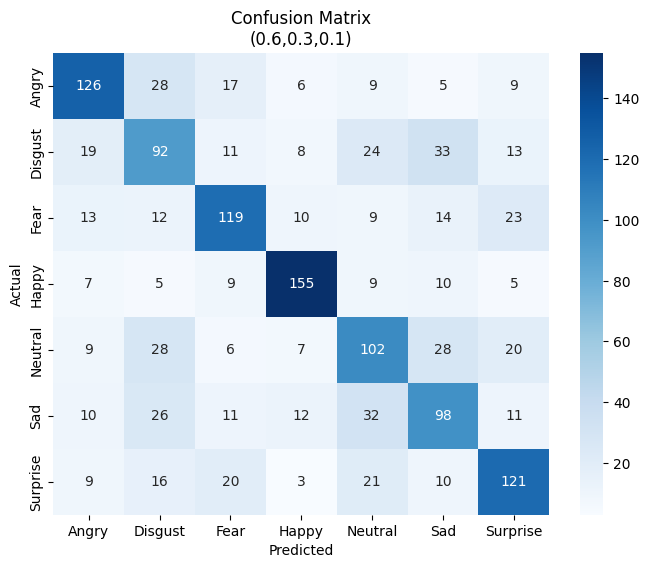

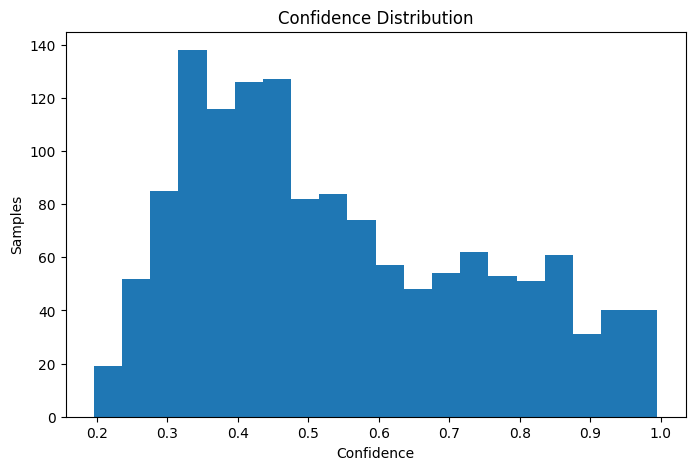


Threshold : 0.4
Accepted : 979
Rejected : 421
Accuracy : 69.15 %

Threshold : 0.5
Accepted : 687
Rejected : 713
Accuracy : 77.87 %

Threshold : 0.6
Accepted : 492
Rejected : 908
Accuracy : 85.37 %

Threshold : 0.7
Accepted : 354
Rejected : 1046
Accuracy : 92.37 %

Threshold : 0.8
Accepted : 218
Rejected : 1182
Accuracy : 98.17 %

Filtered Accuracy : 85.37 %


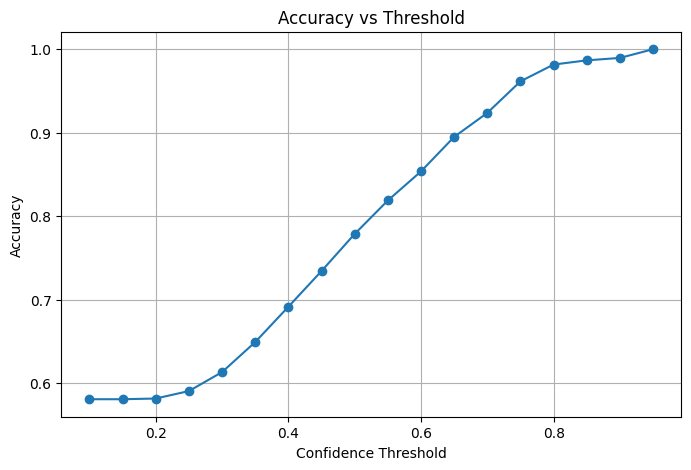

Weights : HOG=0.7 | MobileNet=0.2 | VGG=0.1
Fusion Shape : (1400, 9892)

Overall Accuracy : 57.79 %

Classification Report

              precision    recall  f1-score   support

       Angry       0.64      0.62      0.63       200
     Disgust       0.43      0.45      0.44       200
        Fear       0.63      0.60      0.62       200
       Happy       0.76      0.76      0.76       200
     Neutral       0.49      0.51      0.50       200
         Sad       0.50      0.49      0.49       200
    Surprise       0.60      0.61      0.61       200

    accuracy                           0.58      1400
   macro avg       0.58      0.58      0.58      1400
weighted avg       0.58      0.58      0.58      1400



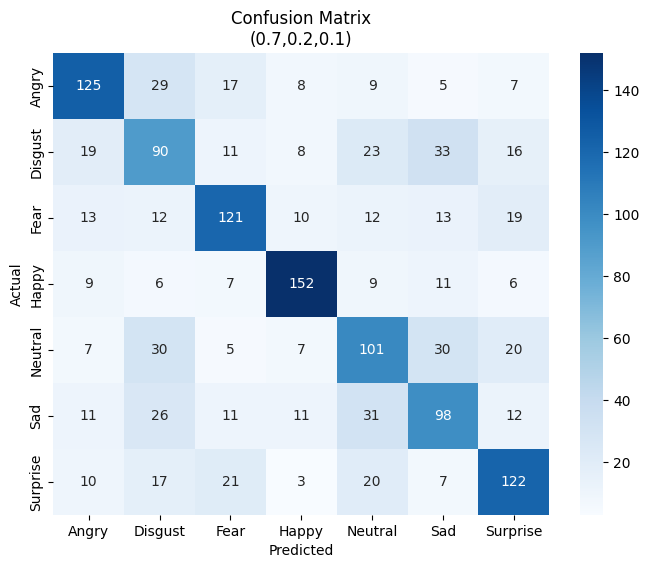

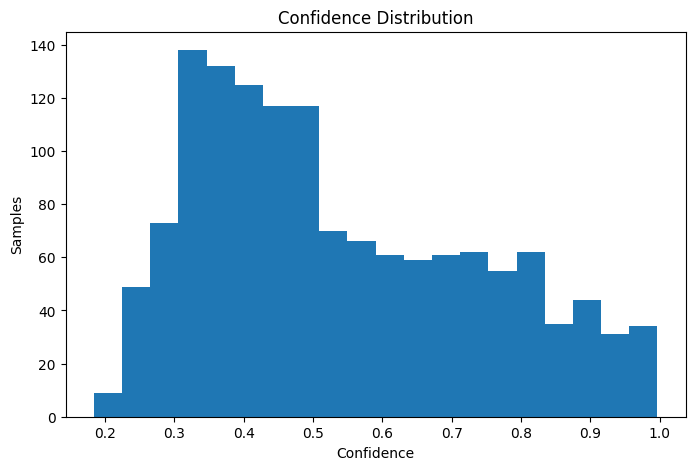


Threshold : 0.4
Accepted : 951
Rejected : 449
Accuracy : 69.3 %

Threshold : 0.5
Accepted : 667
Rejected : 733
Accuracy : 77.66 %

Threshold : 0.6
Accepted : 486
Rejected : 914
Accuracy : 84.77 %

Threshold : 0.7
Accepted : 340
Rejected : 1060
Accuracy : 93.82 %

Threshold : 0.8
Accepted : 193
Rejected : 1207
Accuracy : 97.93 %

Filtered Accuracy : 84.77 %


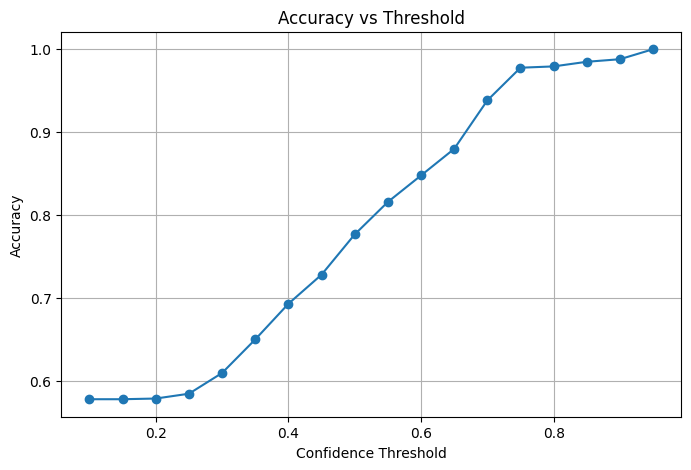

Weights : HOG=0.5 | MobileNet=0.4 | VGG=0.1
Fusion Shape : (1400, 9892)

Overall Accuracy : 58.5 %

Classification Report

              precision    recall  f1-score   support

       Angry       0.65      0.65      0.65       200
     Disgust       0.43      0.45      0.44       200
        Fear       0.64      0.59      0.61       200
       Happy       0.77      0.79      0.78       200
     Neutral       0.49      0.51      0.50       200
         Sad       0.51      0.49      0.50       200
    Surprise       0.61      0.62      0.61       200

    accuracy                           0.58      1400
   macro avg       0.59      0.59      0.59      1400
weighted avg       0.59      0.58      0.59      1400



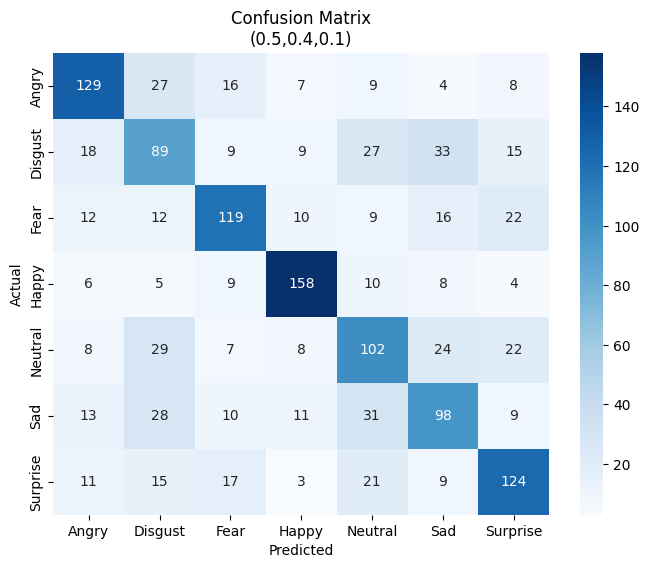

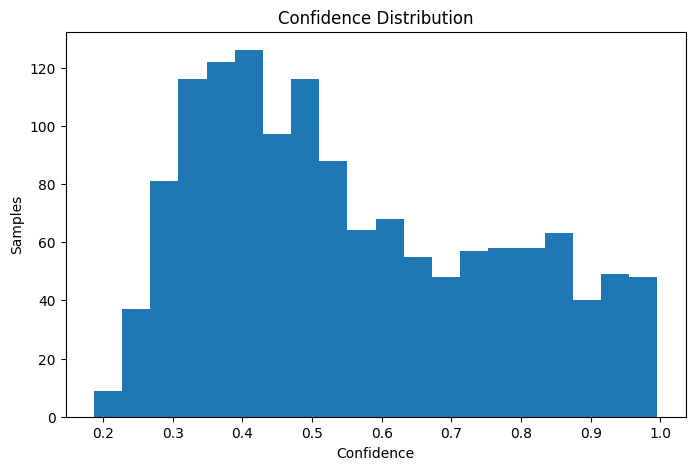


Threshold : 0.4
Accepted : 993
Rejected : 407
Accuracy : 70.19 %

Threshold : 0.5
Accepted : 728
Rejected : 672
Accuracy : 77.2 %

Threshold : 0.6
Accepted : 526
Rejected : 874
Accuracy : 85.55 %

Threshold : 0.7
Accepted : 391
Rejected : 1009
Accuracy : 91.3 %

Threshold : 0.8
Accepted : 254
Rejected : 1146
Accuracy : 97.64 %

Filtered Accuracy : 85.55 %


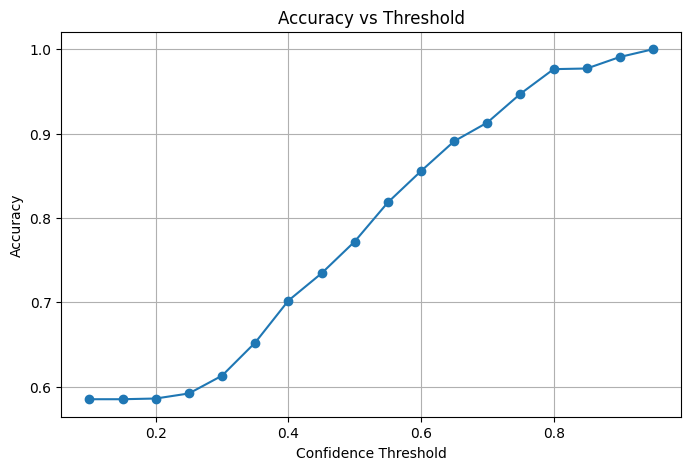

Weights : HOG=0.35 | MobileNet=0.35 | VGG=0.3
Fusion Shape : (1400, 9892)

Overall Accuracy : 59.14 %

Classification Report

              precision    recall  f1-score   support

       Angry       0.66      0.66      0.66       200
     Disgust       0.43      0.46      0.44       200
        Fear       0.64      0.62      0.63       200
       Happy       0.77      0.79      0.78       200
     Neutral       0.49      0.52      0.50       200
         Sad       0.53      0.49      0.51       200
    Surprise       0.63      0.61      0.62       200

    accuracy                           0.59      1400
   macro avg       0.59      0.59      0.59      1400
weighted avg       0.59      0.59      0.59      1400



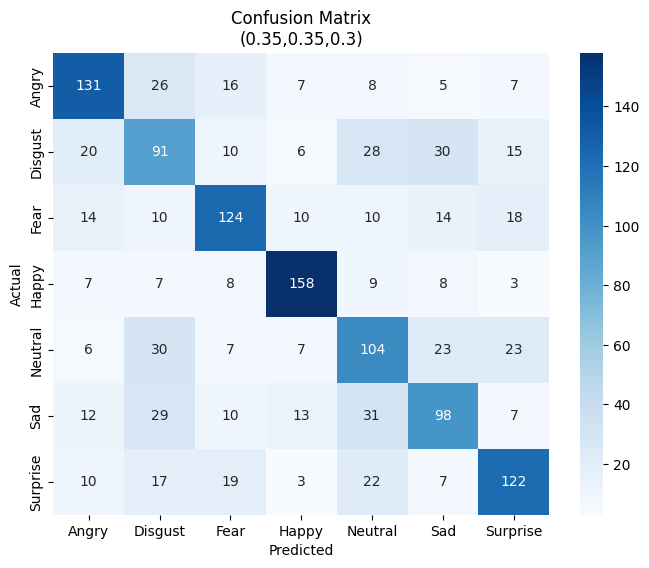

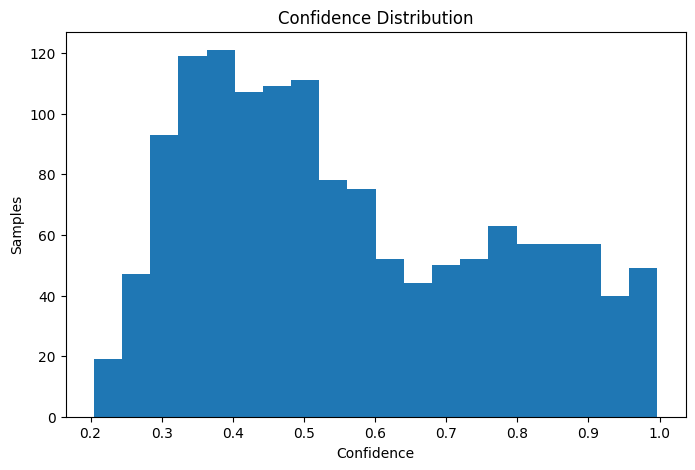


Threshold : 0.4
Accepted : 1013
Rejected : 387
Accuracy : 69.4 %

Threshold : 0.5
Accepted : 739
Rejected : 661
Accuracy : 78.08 %

Threshold : 0.6
Accepted : 522
Rejected : 878
Accuracy : 86.97 %

Threshold : 0.7
Accepted : 402
Rejected : 998
Accuracy : 92.29 %

Threshold : 0.8
Accepted : 259
Rejected : 1141
Accuracy : 97.3 %

Filtered Accuracy : 86.97 %


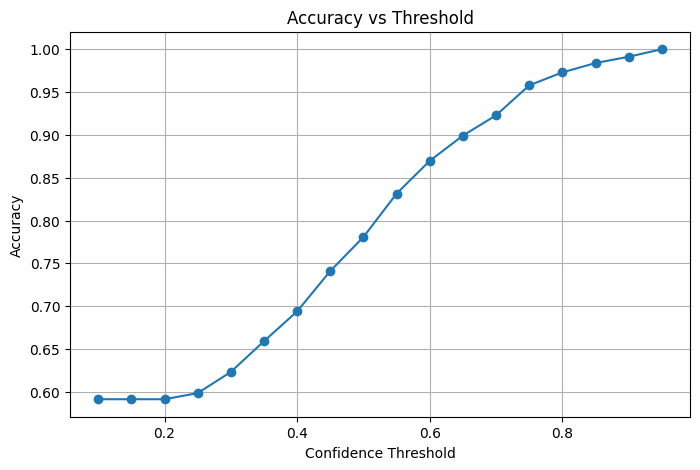

Weights : HOG=0.34 | MobileNet=0.33 | VGG=0.33
Fusion Shape : (1400, 9892)

Overall Accuracy : 59.14 %

Classification Report

              precision    recall  f1-score   support

       Angry       0.65      0.65      0.65       200
     Disgust       0.42      0.45      0.44       200
        Fear       0.64      0.61      0.63       200
       Happy       0.77      0.79      0.78       200
     Neutral       0.50      0.53      0.51       200
         Sad       0.53      0.48      0.51       200
    Surprise       0.64      0.62      0.63       200

    accuracy                           0.59      1400
   macro avg       0.59      0.59      0.59      1400
weighted avg       0.59      0.59      0.59      1400



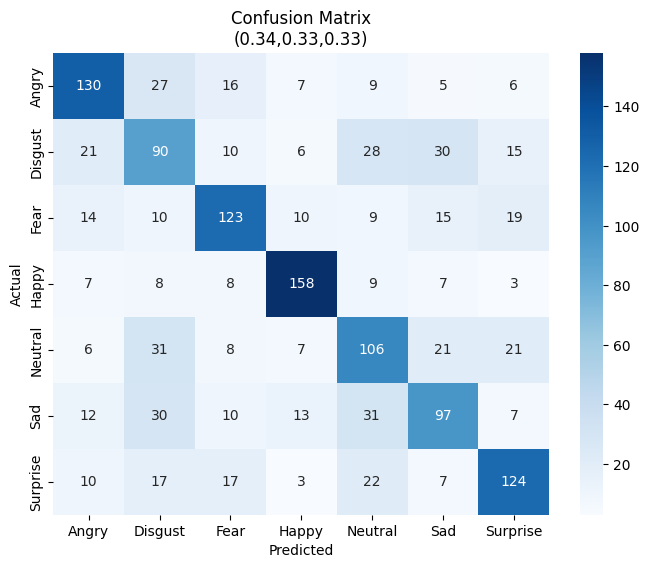

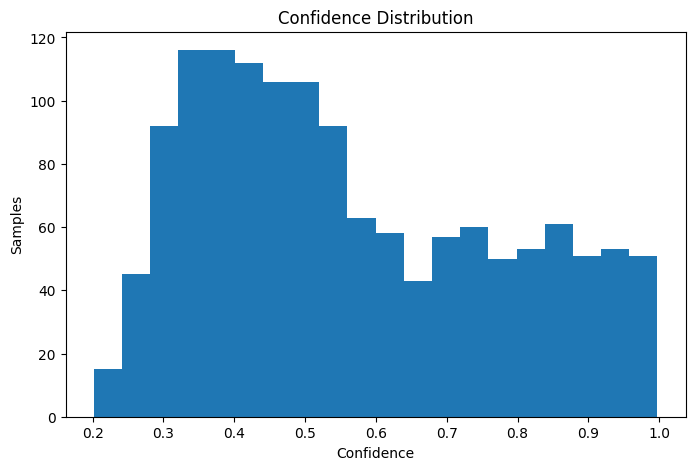


Threshold : 0.4
Accepted : 1018
Rejected : 382
Accuracy : 69.16 %

Threshold : 0.5
Accepted : 741
Rejected : 659
Accuracy : 77.46 %

Threshold : 0.6
Accepted : 536
Rejected : 864
Accuracy : 87.13 %

Threshold : 0.7
Accepted : 406
Rejected : 994
Accuracy : 92.36 %

Threshold : 0.8
Accepted : 267
Rejected : 1133
Accuracy : 96.63 %

Filtered Accuracy : 87.13 %


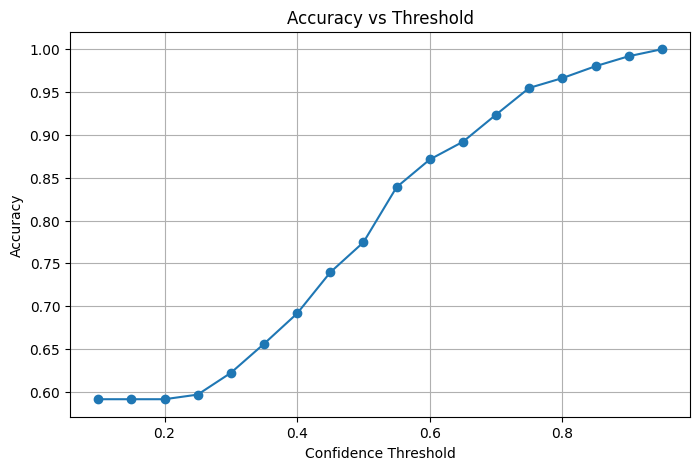

In [68]:
results = []

results.append(
    evaluate_fusion(
        0.60,
        0.30,
        0.10,
        X_hog_scaled,
        X_mobilenet_scaled,
        X_vgg_scaled,
        labels,
        emotion_names,
        cv
    )
)

results.append(
    evaluate_fusion(
        0.70,
        0.20,
        0.10,
        X_hog_scaled,
        X_mobilenet_scaled,
        X_vgg_scaled,
        labels,
        emotion_names,
        cv
    )
)

results.append(
    evaluate_fusion(
        0.50,
        0.40,
        0.10,
        X_hog_scaled,
        X_mobilenet_scaled,
        X_vgg_scaled,
        labels,
        emotion_names,
        cv
    )
)

results.append(
    evaluate_fusion(
        0.35,
        0.35,
        0.30,
        X_hog_scaled,
        X_mobilenet_scaled,
        X_vgg_scaled,
        labels,
        emotion_names,
        cv
    )
)

results.append(
    evaluate_fusion(
        0.34,
        0.33,
        0.33,
        X_hog_scaled,
        X_mobilenet_scaled,
        X_vgg_scaled,
        labels,
        emotion_names,
        cv
    )
)

In [69]:
results_df = pd.DataFrame(results)

results_df.columns = [
    "Weights",
    "Overall Accuracy",
    "Filtered Accuracy"
]

results_df

,Weights,Overall Accuracy,Filtered Accuracy
0,"0.6,0.3,0.1",58.071429,85.365854
1,"0.7,0.2,0.1",57.785714,84.773663
2,"0.5,0.4,0.1",58.500000,85.551331
3,"0.35,0.35,0.3",59.142857,86.973180
4,"0.34,0.33,0.33",59.142857,87.126866


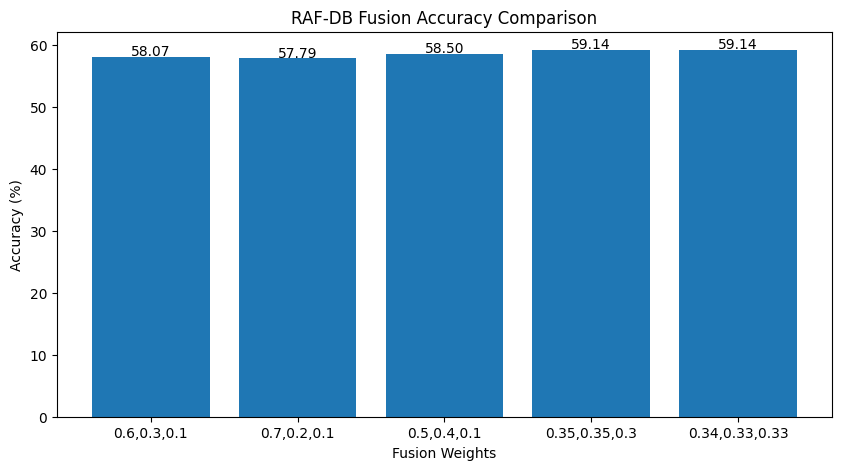

In [70]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    results_df["Weights"],
    results_df["Overall Accuracy"]
)

plt.ylabel("Accuracy (%)")

plt.xlabel("Fusion Weights")

plt.title(
    "RAF-DB Fusion Accuracy Comparison"
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.2,
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.show()

In [71]:
best_row = results_df.loc[
    results_df[
        "Overall Accuracy"
    ].idxmax()
]

print(best_row)

Weights              0.35,0.35,0.3
Overall Accuracy         59.142857
Filtered Accuracy         86.97318
Name: 3, dtype: object
